Kaggle Dataset Download

In [1]:
import os

# 1. Setup API Key
os.environ["KAGGLE_USERNAME"] = "muhammadaliffandy"
os.environ["KAGGLE_KEY"] = "KGAT_6cf20e173408038efc8c307643a53392"

# 2. Install kagglehub
!pip install -q kagglehub

import kagglehub

print("⏳ Memulai download dataset BraTS2020...")
# Download (ini akan masuk ke cache dulu)
download_path = kagglehub.dataset_download("andrewmvd/ct-low-dose-reconstruction")

print(f"✅ Download selesai di: {download_path}")

# 3. Pindahkan secara paksa menggunakan perintah terminal (Linux cp)
# Kita pakai -r (recursive) untuk copy folder dan isinya
print("🚚 Memindahkan folder ke /content agar lebih mudah diakses...")

!cp -r "{download_path}" /content/




⏳ Memulai download dataset BraTS2020...


100%|██████████| 18.3G/18.3G [03:12<00:00, 102MB/s]

Extracting files...


✅ Download selesai di: /root/.cache/kagglehub/datasets/andrewmvd/ct-low-dose-reconstruction/versions/2
🚚 Memindahkan folder ke /content agar lebih mudah diakses...


Training Preparation

In [ ]:
import os

def print_directory_tree(startpath, max_files=5):
    print(f"🔍 --- Scanning Directory Tree for: {startpath} --- 🔍\n")

    if not os.path.exists(startpath):
        print(f"❌ Error: The path '{startpath}' does not exist. Please check the spelling.")
        return

    for root, dirs, files in os.walk(startpath):
        # Calculate the depth level for indentation
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * level

        # Print the current folder name
        folder_name = os.path.basename(root)
        if folder_name == '':
            folder_name = startpath
        print(f"{indent}📁 {folder_name}/")

        # Print the files inside this folder (limited to max_files)
        subindent = ' ' * 4 * (level + 1)
        for i, f in enumerate(files):
            if i < max_files:
                print(f"{subindent}📄 {f}")
            elif i == max_files:
                print(f"{subindent}└── ... and {len(files) - max_files} more files")
                break

# --- EXECUTE SCRIPT ---
folder_to_scan = "/content/Dataset"
print_directory_tree(folder_to_scan)

🔍 --- Scanning Directory Tree for: /content/Dataset --- 🔍

📁 Dataset/
    📄 metadata.csv
    📁 Preprocessed_256x256/
        📁 256/
            📁 Full Dose/
                📁 1mm/
                    📁 Sharp Kernel (D45)/
                        📁 L286/
                            📄 L286_FD_1_SHARP_1.CT.0002.0446.2016.01.21.18.19.18.666560.404714452.png
                            📄 L286_FD_1_SHARP_1.CT.0002.0404.2016.01.21.18.19.18.666560.404713444.png
                            📄 L286_FD_1_SHARP_1.CT.0002.0181.2016.01.21.18.19.18.666560.404708092.png
                            📄 L286_FD_1_SHARP_1.CT.0002.0221.2016.01.21.18.19.18.666560.404709052.png
                            📄 L286_FD_1_SHARP_1.CT.0002.0351.2016.01.21.18.19.18.666560.404712172.png
                            └── ... and 520 more files
                        📁 L310/
                            📄 L310_FD_1_SHARP_1.CT.0002.0533.2016.01.21.18.20.47.435560.404621787.png
                            📄 L310_FD_1_SHARP_1

🔍 Checking CUDA / GPU Availability...
✅ GPU Detected: /physical_device:GPU:0
--- Loading DICOM dataset from: /content/Dataset/CT_low_dose_reconstruction_dataset/Original Data ---
🔍 Scanning directories for medical image files (.IMA)...
📦 Found 16628 Full Dose (Label 0) and 16628 Quarter Dose (Label 1) images.
🚀 Processing Full Dose (Limit: 500)...
🚀 Processing Quarter Dose (Limit: 500)...
✅ Data loading complete! Total images loaded: 1000

🔀 Shuffling dataset...
Training samples: 800 | Testing samples: 200

--- Training Multi-Task Mod-Seg-SE(2) Model ---
--- Building Mod-Seg-SE(2) Multi-Task Architecture ---
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 55s 441ms/step - class_output_accuracy: 0.4988 - class_output_loss: 0.7091 - loss: 1.0111 - seg_output_accuracy: 0.9116 - seg_output_loss: 0.3020 - val_class_output_accuracy: 0.5000 - val_class_output_loss: 0.6933 - val_loss: 0.6931 - val_seg_output_accuracy: 1.0000 - val_seg_output_loss: 2.1249e-05
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 229

✅ Multi-task model saved to ./new_mod_seg_se_model/mod_seg_se2_model.h5.

--- Evaluating Model on Test Data ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 267ms/step

 🎯 CLASSIFICATION TEST ACCURACY: 99.00%

Classification Report:
              precision    recall  f1-score   support

   Full_Dose       0.98      1.00      0.99       100
Quarter_Dose       1.00      0.98      0.99       100

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



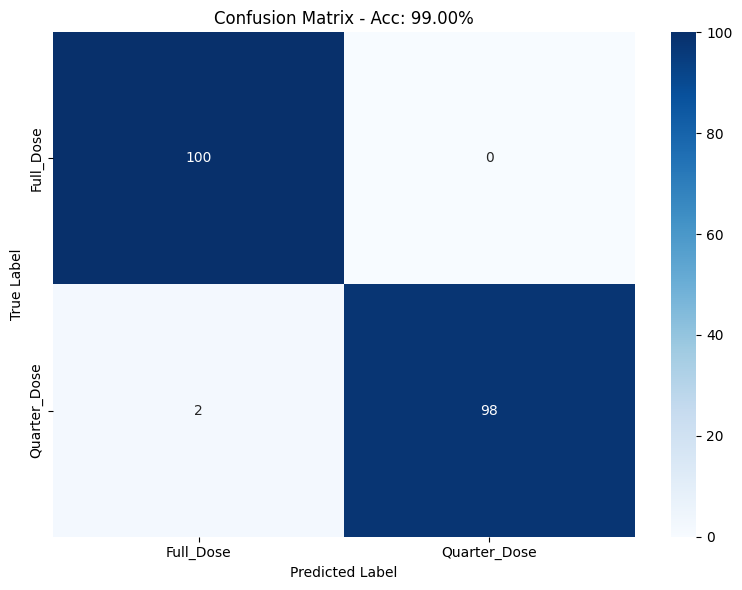

✅ Confusion Matrix plot saved to ./new_mod_seg_se_model/confusion_matrix.png.

🎉 MULTI-TASK PIPELINE COMPLETED SUCCESSFULLY! 🎉


In [4]:
import os
import cv2
import glob
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

import pydicom
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.utils import shuffle

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, UpSampling2D,
                                     Flatten, Dense, Concatenate, GlobalAveragePooling2D,
                                     Reshape, Multiply, Dropout)
from tensorflow.keras.utils import to_categorical

# --- CONFIGURATIONS & CUDA SETUP ---
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

print("🔍 Checking CUDA / GPU Availability...")
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    print(f"✅ GPU Detected: {physical_devices[0].name}")
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
else:
    print("⚠️ WARNING: No GPU detected. Training will fall back to CPU and might be slow.")

IMG_SIZE = (256, 256)
CLASS_NAMES = ['Full_Dose', 'Quarter_Dose']
NUM_CLASSES = len(CLASS_NAMES)
SAVE_DIR = "./new_mod_seg_se_model"

if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

PATHS = {
    "keras": os.path.join(SAVE_DIR, "mod_seg_se2_model.h5"),
    "confusion_matrix": os.path.join(SAVE_DIR, "confusion_matrix.png")
}

# ==============================================================================
# 1. SQUEEZE-AND-EXCITATION (SE) BLOCK
# ==============================================================================
def se_block(input_tensor, ratio=8):
    """
    Applies a Squeeze-and-Excitation block to the input tensor.
    This helps the network focus on the most informative feature channels.
    """
    filters = input_tensor.shape[-1]

    # Squeeze step: Global Average Pooling
    se = GlobalAveragePooling2D()(input_tensor)
    se = Reshape((1, 1, filters))(se)

    # Excitation step: Two fully connected (Dense) layers
    se = Dense(filters // ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
    se = Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)

    # Scale the original input feature map
    x = Multiply()([input_tensor, se])
    return x

# ==============================================================================
# 2. DATA LOADING (CLASSIFICATION + SEGMENTATION MASKS)
# ==============================================================================
def load_dataset(base_dir):
    print(f"--- Loading DICOM dataset from: {base_dir} ---")

    ld_dir = os.path.join(base_dir, "Quarter Dose")
    nd_dir = os.path.join(base_dir, "Full Dose")

    if not os.path.exists(ld_dir) or not os.path.exists(nd_dir):
        print(f"❌ Error: Directories not found inside {base_dir}!")
        return None, None, None

    exts = ("*.IMA", "*.ima", "*.dcm")
    ld_files, nd_files = [], []

    print("🔍 Scanning directories for medical image files (.IMA)...")
    for ext in exts:
        ld_files.extend(glob.glob(os.path.join(ld_dir, "**", ext), recursive=True))
        nd_files.extend(glob.glob(os.path.join(nd_dir, "**", ext), recursive=True))

    ld_files, nd_files = sorted(ld_files), sorted(nd_files)
    print(f"📦 Found {len(nd_files)} Full Dose (Label 0) and {len(ld_files)} Quarter Dose (Label 1) images.")

    images, masks, labels = [], [], []

    LIMIT = 500

    def process_dicom(file_path):
        try:
            dcm = pydicom.dcmread(file_path)
            img_array = dcm.pixel_array.astype(np.float32)
            img_normalized = (img_array - np.min(img_array)) / (np.max(img_array) - np.min(img_array) + 1e-6) * 255.0
            img_uint8 = img_normalized.astype(np.uint8)
            img_rgb = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2RGB)
            img_resized = cv2.resize(img_rgb, IMG_SIZE)

            # --- IMPORTANT: DUMMY MASK GENERATION ---
            # Replace this block with your actual mask loading logic!
            # Example: mask_path = file_path.replace('Original Data', 'Masks')
            # mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            dummy_mask = np.zeros(IMG_SIZE, dtype=np.float32)

            return img_resized, dummy_mask

        except Exception as e:
            print(f"⚠️ Error reading {file_path}: {e}")
            return None, None

    print(f"🚀 Processing Full Dose (Limit: {LIMIT})...")
    for i, file_path in enumerate(nd_files[:LIMIT]):
        img_rgb, mask = process_dicom(file_path)
        if img_rgb is not None:
            images.append(img_rgb.astype(np.float32) / 255.0)
            masks.append(np.expand_dims(mask, axis=-1)) # Add channel dimension for binary mask
            labels.append(0)

    print(f"🚀 Processing Quarter Dose (Limit: {LIMIT})...")
    for i, file_path in enumerate(ld_files[:LIMIT]):
        img_rgb, mask = process_dicom(file_path)
        if img_rgb is not None:
            images.append(img_rgb.astype(np.float32) / 255.0)
            masks.append(np.expand_dims(mask, axis=-1))
            labels.append(1)

    print(f"✅ Data loading complete! Total images loaded: {len(images)}")
    return np.array(images), np.array(masks), np.array(labels)

# ==============================================================================
# 3. BUILD MOD-SEG-SE(2) MULTI-TASK ARCHITECTURE
# ==============================================================================
def build_mod_seg_se2(input_shape=(256, 256, 3)):
    print("--- Building Mod-Seg-SE(2) Multi-Task Architecture ---")

    inputs = Input(shape=input_shape, name="image_input")

    # --- ENCODER (Contracting Path) ---
    c1 = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(32, (3, 3), activation='relu', padding='same')(c1)
    c1 = se_block(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(64, (3, 3), activation='relu', padding='same')(c2)
    c2 = se_block(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    # --- BOTTLENECK ---
    bn = Conv2D(128, (3, 3), activation='relu', padding='same')(p2)
    bn = Conv2D(128, (3, 3), activation='relu', padding='same')(bn)
    bn = se_block(bn)

    # --- BRANCH 1: CLASSIFICATION HEAD ---
    # Pooling the bottleneck features for classification
    cls = GlobalAveragePooling2D(name="gap_classification")(bn)
    cls = Dense(64, activation='relu')(cls)
    cls = Dropout(0.5)(cls)
    class_output = Dense(NUM_CLASSES, activation='softmax', name="class_output")(cls)

    # --- BRANCH 2: DECODER (Segmentation Path) ---
    u1 = UpSampling2D((2, 2))(bn)
    concat1 = Concatenate()([u1, c2])
    d1 = Conv2D(64, (3, 3), activation='relu', padding='same')(concat1)
    d1 = Conv2D(64, (3, 3), activation='relu', padding='same')(d1)
    d1 = se_block(d1)

    u2 = UpSampling2D((2, 2))(d1)
    concat2 = Concatenate()([u2, c1])
    d2 = Conv2D(32, (3, 3), activation='relu', padding='same')(concat2)
    d2 = Conv2D(32, (3, 3), activation='relu', padding='same')(d2)
    d2 = se_block(d2)

    # Assuming a binary segmentation task (e.g., segmenting anomalies)
    seg_output = Conv2D(1, (1, 1), activation='sigmoid', name="seg_output")(d2)

    # --- COMPILE MODEL ---
    model = Model(inputs=inputs, outputs=[class_output, seg_output])

    # Define distinct losses and weights for both tasks
    losses = {
        "class_output": "categorical_crossentropy",
        "seg_output": "binary_crossentropy"
    }

    loss_weights = {
        "class_output": 1.0,
        "seg_output": 1.0  # Adjust weights if one task is prioritizing over another
    }

    model.compile(optimizer='adam', loss=losses, loss_weights=loss_weights,
                  metrics={'class_output': 'accuracy', 'seg_output': 'accuracy'})

    return model

# ==============================================================================
# 4. MAIN TRAINING PIPELINE
# ==============================================================================
def train_pipeline(data_dir):
    X_img, Y_mask, y_labels = load_dataset(data_dir)
    if X_img is None: return

    print("\n🔀 Shuffling dataset...")
    X_img, Y_mask, y_labels = shuffle(X_img, Y_mask, y_labels, random_state=42)
    y_cat = to_categorical(y_labels, num_classes=NUM_CLASSES)

    # Split dataset (80% Train, 20% Test)
    X_train_img, X_test_img, Y_train_mask, Y_test_mask, Y_train_cls, Y_test_cls = train_test_split(
        X_img, Y_mask, y_cat, test_size=0.2, random_state=42, stratify=y_labels
    )

    print(f"Training samples: {len(X_train_img)} | Testing samples: {len(X_test_img)}")

    print("\n--- Training Multi-Task Mod-Seg-SE(2) Model ---")
    model = build_mod_seg_se2(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    with tf.device('/GPU:0'):
        history = model.fit(
            X_train_img,
            {"class_output": Y_train_cls, "seg_output": Y_train_mask},
            validation_data=(X_test_img, {"class_output": Y_test_cls, "seg_output": Y_test_mask}),
            epochs=20,
            batch_size=16
        )

    model.save(PATHS["keras"])
    print(f"✅ Multi-task model saved to {PATHS['keras']}.")

    # ==========================================================================
    # 5. EVALUATION
    # ==========================================================================
    print("\n--- Evaluating Model on Test Data ---")

    # Predict returns a list: [classification_predictions, segmentation_predictions]
    preds = model.predict(X_test_img)
    cls_preds_proba = preds[0]

    y_test_labels = np.argmax(Y_test_cls, axis=1)
    y_pred_labels = np.argmax(cls_preds_proba, axis=1)

    accuracy_pct = accuracy_score(y_test_labels, y_pred_labels) * 100

    print("\n" + "="*50)
    print(f" 🎯 CLASSIFICATION TEST ACCURACY: {accuracy_pct:.2f}%")
    print("="*50 + "\n")

    cm = confusion_matrix(y_test_labels, y_pred_labels)
    print("Classification Report:")
    print(classification_report(y_test_labels, y_pred_labels, target_names=CLASS_NAMES))

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'Confusion Matrix - Acc: {accuracy_pct:.2f}%')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

    plt.tight_layout()
    plt.savefig(PATHS["confusion_matrix"])
    plt.show()
    print(f"✅ Confusion Matrix plot saved to {PATHS['confusion_matrix']}.")

    print("\n🎉 MULTI-TASK PIPELINE COMPLETED SUCCESSFULLY! 🎉")

# --- EXECUTE SCRIPT ---
if __name__ == "__main__":
    BASE_DIRECTORY = "/content/Dataset/CT_low_dose_reconstruction_dataset/Original Data"
    train_pipeline(BASE_DIRECTORY)

In [3]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 27.0 MB/s eta 0:00:00


In [7]:
cp -r /content/new_mod_seg_se_model /content/drive/MyDrive/ldct_model_new

In [6]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive
